In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [2]:
os.getcwd()

'/Users/mubashariqbal/TWINE'

In [ ]:
df = pd.read_csv(r'/right_arm.csv')

df.head()

,Timestamp,Actual Joint Positions,Actual Joint Velocities,Actual Joint Currents,Actual Cartesian Coordinates,Actual Tool Speed,Generalized Forces,Temperature of Each Joint,Execution Time,Safety Status,Tool Acceleration,Norm of Cartesion Linear Momentum,Robot Current,Joint Voltages,Elbow Position,Elbow Velocity,Tool Current,Tool Temperature,TCP Force,Anomaly State
0,257258.126,"[-1.5707390944110315, -1.5707948964885254, -1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.18499481678009033, 1.1043120622634888, 1.38...","[-0.133089990415502, -0.4433227297722474, 0.48...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[-0.015098106867198664, -0.38619858377727334, ...","[34.375, 36.875, 39.6875, 42.8125, 45.0, 45.3125]",0.833027,1,"[-9.423578262329102, 0.26815059781074524, 0.11...",0.000000,0.560617,"[47.48460006713867, 47.61359786987305, 47.6279...","[-0.07999999993886807, -4.2302395934749395e-06...","[0.0, 0.0, 0.0]",0.069408,39.6250,0.693609,0
1,257258.176,"[-1.5707176367389124, -1.570843359033102, -1.5...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.16534548997879028, 1.0664139986038208, 1.40...","[-0.13308335724829182, -0.44333549960206997, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[-0.04213328588448917, -0.4293152706290817, 0....","[34.375, 36.875, 39.6875, 42.8125, 45.0, 45.3125]",0.898871,1,"[-9.346963882446289, 0.2298433631658554, 0.114...",0.000000,0.497956,"[47.5275993347168, 47.64226150512695, 47.65659...","[-0.07999999890089683, -1.7749906051421094e-05...","[0.0, 0.0, 0.0]",0.064909,39.6250,0.685211,0
2,257258.226,"[-1.570730988179342, -1.5708185635008753, -1.5...","[0.0, 0.0, 0.0, -0.010884314775466919, 0.0, 0.0]","[0.1645040214061737, 1.0770467519760132, 1.354...","[-0.13307894938257267, -0.44333179729023336, 0...","[-2.003684872597315e-06, -0.000926684519370717...","[0.05686369196465915, -0.2101876951251029, 0.9...","[34.375, 36.875, 39.6875, 42.8125, 45.0, 45.3125]",1.048140,1,"[-9.385271072387695, 0.2298433631658554, 0.191...",0.004019,0.504669,"[47.513267517089844, 47.670928955078125, 47.67...","[-0.07999999952532996, -1.0642838973058337e-05...","[0.0, 0.0, 0.0]",0.071274,39.6250,0.944428,0
3,257258.276,"[-1.570660416279928, -1.5707827371409913, -1.5...","[0.0, 0.0, 0.0, -0.08753828704357147, 0.0, 0.0]","[0.18218308687210083, 1.0735350847244263, 1.37...","[-0.13305178855972016, -0.443525353390802, 0.4...","[-1.5362262575268616e-05, -0.00740704821459850...","[0.014812691800918066, -0.0035357919273737524,...","[34.375, 36.875, 39.6875, 42.8125, 45.0, 45.3125]",1.124447,1,"[-9.327810287475586, 0.2298433631658554, 0.191...",0.026350,0.506904,"[47.55626678466797, 47.713924407958984, 47.670...","[-0.07999999976091744, -7.5630809928628735e-06...","[0.0, 0.0, 0.0]",0.071954,39.6250,0.891657,0
4,257258.326,"[-1.570700470601217, -1.570839067498678, -1.57...","[0.0, 0.0, 0.0, -0.14845426380634308, 0.0, 0.0]","[0.1679745316505432, 1.0931836366653442, 1.374...","[-0.13306762017073243, -0.44405501412764015, 0...","[-2.5524599112393154e-05, -0.01234826561117640...","[-0.0066400665555922875, -0.33964563763481687,...","[34.375, 36.875, 39.6875, 42.75, 45.0, 45.3125]",1.072475,1,"[-9.404424667358398, 0.3064578175544739, 0.057...",0.048680,0.457674,"[47.55626678466797, 47.670928955078125, 47.685...","[-0.07999999868460166, -1.8077993842428327e-05...","[0.0, 0.0, 0.0]",0.066182,39.6875,0.750271,0


In [4]:
#replace blank spaces in the column names with '_'
df.columns = df.columns.str.replace(' ', '_')

In [5]:
import ast

# Detect which columns contain list-type values
def is_list_column(series):
    sample = series.dropna().iloc[0]
    if isinstance(sample, list):
        return True
    if isinstance(sample, str):
        try:
            return isinstance(ast.literal_eval(sample), list)
        except:
            return False
    return False

list_columns = [col for col in df.columns if is_list_column(df[col])]
print(f"Found {len(list_columns)} list-format columns:")
for col in list_columns:
    print(f"  - {col}")

Found 11 list-format columns:
  - Actual_Joint_Positions
  - Actual_Joint_Velocities
  - Actual_Joint_Currents
  - Actual_Cartesian_Coordinates
  - Actual_Tool_Speed
  - Generalized_Forces
  - Temperature_of_Each_Joint
  - Tool_Acceleration
  - Joint_Voltages
  - Elbow_Position
  - Elbow_Velocity


In [6]:
expanded_dfs = [df.drop(columns=list_columns)]  # start with non-list columns

for col in list_columns:
    # Parse string to list if needed
    parsed = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Get number of elements in the list
    n_elements = len(parsed.iloc[0])
    
    # Create clean column names from original column name
    clean_name = col.strip().replace(' ', '_')
    new_col_names = [f"{clean_name}_{i+1}" for i in range(n_elements)]
    
    # Expand into separate columns
    expanded = pd.DataFrame(parsed.tolist(), columns=new_col_names, index=df.index)
    expanded_dfs.append(expanded)
    
    print(f"✔ '{col}' → expanded into {n_elements} columns: {new_col_names}")

# Combine everything into one flat dataframe
df_expanded = pd.concat(expanded_dfs, axis=1)

print(f"\nOriginal shape : {df.shape}")
print(f"Expanded shape : {df_expanded.shape}")
df_expanded.head()

✔ 'Actual_Joint_Positions' → expanded into 6 columns: ['Actual_Joint_Positions_1', 'Actual_Joint_Positions_2', 'Actual_Joint_Positions_3', 'Actual_Joint_Positions_4', 'Actual_Joint_Positions_5', 'Actual_Joint_Positions_6']
✔ 'Actual_Joint_Velocities' → expanded into 6 columns: ['Actual_Joint_Velocities_1', 'Actual_Joint_Velocities_2', 'Actual_Joint_Velocities_3', 'Actual_Joint_Velocities_4', 'Actual_Joint_Velocities_5', 'Actual_Joint_Velocities_6']
✔ 'Actual_Joint_Currents' → expanded into 6 columns: ['Actual_Joint_Currents_1', 'Actual_Joint_Currents_2', 'Actual_Joint_Currents_3', 'Actual_Joint_Currents_4', 'Actual_Joint_Currents_5', 'Actual_Joint_Currents_6']
✔ 'Actual_Cartesian_Coordinates' → expanded into 6 columns: ['Actual_Cartesian_Coordinates_1', 'Actual_Cartesian_Coordinates_2', 'Actual_Cartesian_Coordinates_3', 'Actual_Cartesian_Coordinates_4', 'Actual_Cartesian_Coordinates_5', 'Actual_Cartesian_Coordinates_6']
✔ 'Actual_Tool_Speed' → expanded into 6 columns: ['Actual_Tool_Spe

,Timestamp,Execution_Time,Safety_Status,Norm_of_Cartesion_Linear_Momentum,Robot_Current,Tool_Current,Tool_Temperature,TCP_Force,Anomaly_State,Actual_Joint_Positions_1,...,Joint_Voltages_3,Joint_Voltages_4,Joint_Voltages_5,Joint_Voltages_6,Elbow_Position_1,Elbow_Position_2,Elbow_Position_3,Elbow_Velocity_1,Elbow_Velocity_2,Elbow_Velocity_3
0,257258.126,0.833027,1,0.000000,0.560617,0.069408,39.6250,0.693609,0,-1.570739,...,47.627930,47.498932,47.384270,47.455936,-0.08,-0.000004,0.3954,0.0,0.0,0.0
1,257258.176,0.898871,1,0.000000,0.497956,0.064909,39.6250,0.685211,0,-1.570718,...,47.656593,47.556267,47.441601,47.484600,-0.08,-0.000018,0.3954,0.0,0.0,0.0
2,257258.226,1.048140,1,0.004019,0.504669,0.071274,39.6250,0.944428,0,-1.570731,...,47.670929,47.527599,47.427269,47.498932,-0.08,-0.000011,0.3954,0.0,0.0,0.0
3,257258.276,1.124447,1,0.026350,0.506904,0.071954,39.6250,0.891657,0,-1.570660,...,47.670929,47.541931,47.455936,47.527599,-0.08,-0.000008,0.3954,0.0,0.0,0.0
4,257258.326,1.072475,1,0.048680,0.457674,0.066182,39.6875,0.750271,0,-1.570700,...,47.685261,47.584930,47.427269,47.498932,-0.08,-0.000018,0.3954,0.0,0.0,0.0


In [25]:
# Columns to always exclude from features
exclude_cols = ['Anomaly_State']

# Original scalar columns you want to keep
scalar_features = ['Norm_of_Cartesion_Linear_Momentum', 'Robot_Current',
                   'Tool_Current', 'Tool_Temperature', 'TCP_Force', 'Execution_Time']

# Auto-collect all expanded list column names
expanded_features = [col for col in df_expanded.columns
                     if any(col.startswith(c.strip().replace(' ', '_'))
                            for c in list_columns)]

# Combine all features
all_features = scalar_features + expanded_features

X = df_expanded[all_features]
y = df_expanded['Anomaly_State']

print(f"Total features : {len(all_features)}")
print(f"Feature list   :")
for f in all_features:
    print(f"  - {f}")

Total features : 63
Feature list   :
  - Norm_of_Cartesion_Linear_Momentum
  - Robot_Current
  - Tool_Current
  - Tool_Temperature
  - TCP_Force
  - Execution_Time
  - Actual_Joint_Positions_1
  - Actual_Joint_Positions_2
  - Actual_Joint_Positions_3
  - Actual_Joint_Positions_4
  - Actual_Joint_Positions_5
  - Actual_Joint_Positions_6
  - Actual_Joint_Velocities_1
  - Actual_Joint_Velocities_2
  - Actual_Joint_Velocities_3
  - Actual_Joint_Velocities_4
  - Actual_Joint_Velocities_5
  - Actual_Joint_Velocities_6
  - Actual_Joint_Currents_1
  - Actual_Joint_Currents_2
  - Actual_Joint_Currents_3
  - Actual_Joint_Currents_4
  - Actual_Joint_Currents_5
  - Actual_Joint_Currents_6
  - Actual_Cartesian_Coordinates_1
  - Actual_Cartesian_Coordinates_2
  - Actual_Cartesian_Coordinates_3
  - Actual_Cartesian_Coordinates_4
  - Actual_Cartesian_Coordinates_5
  - Actual_Cartesian_Coordinates_6
  - Actual_Tool_Speed_1
  - Actual_Tool_Speed_2
  - Actual_Tool_Speed_3
  - Actual_Tool_Speed_4
  - Actu

In [26]:
print("X shape :", X.shape)
print("y shape :", y.shape)
print("\nAny nulls in X:", X.isnull().sum().sum())
print("Any nulls in y:", y.isnull().sum())
print("\nSample of expanded features:")
X.head(3)

X shape : (1762650, 63)
y shape : (1762650,)

Any nulls in X: 0
Any nulls in y: 0

Sample of expanded features:


,Norm_of_Cartesion_Linear_Momentum,Robot_Current,Tool_Current,Tool_Temperature,TCP_Force,Execution_Time,Actual_Joint_Positions_1,Actual_Joint_Positions_2,Actual_Joint_Positions_3,Actual_Joint_Positions_4,...,Joint_Voltages_3,Joint_Voltages_4,Joint_Voltages_5,Joint_Voltages_6,Elbow_Position_1,Elbow_Position_2,Elbow_Position_3,Elbow_Velocity_1,Elbow_Velocity_2,Elbow_Velocity_3
0,0.000000,0.560617,0.069408,39.625,0.693609,0.833027,-1.570739,-1.570795,-1.570794,-0.000021,...,47.627930,47.498932,47.384270,47.455936,-0.08,-0.000004,0.3954,0.0,0.0,0.0
1,0.000000,0.497956,0.064909,39.625,0.685211,0.898871,-1.570718,-1.570843,-1.570707,-0.000038,...,47.656593,47.556267,47.441601,47.484600,-0.08,-0.000018,0.3954,0.0,0.0,0.0
2,0.004019,0.504669,0.071274,39.625,0.944428,1.048140,-1.570731,-1.570819,-1.570744,-0.000074,...,47.670929,47.527599,47.427269,47.498932,-0.08,-0.000011,0.3954,0.0,0.0,0.0


In [27]:
# ── 2. Train / Test Split (80 / 20) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class balance in both splits
)
 
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}\n")
 

Training samples : 1410120
Testing  samples : 352530



In [28]:
# ── 3. Model Definition & Training ───────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=None,         # grow trees until pure leaves
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # use all available CPU cores
)
 
rf_model.fit(X_train, y_train)
print("Model training complete.\n")

Model training complete.



In [29]:
# ── 4. Predictions ────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)
 
# ── 5. Evaluation Metrics ─────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='weighted', zero_division=0)
cm        = confusion_matrix(y_test, y_pred)
 
print("=" * 45)
print("         EVALUATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
 
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
 
print("Confusion Matrix:")
print(cm)

         EVALUATION METRICS
  Accuracy  : 0.9646  (96.46%)
  Precision : 0.9645
  Recall    : 0.9646
  F1-Score  : 0.9645

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    283410
           1       0.91      0.91      0.91     69120

    accuracy                           0.96    352530
   macro avg       0.94      0.94      0.94    352530
weighted avg       0.96      0.96      0.96    352530

Confusion Matrix:
[[277440   5970]
 [  6524  62596]]


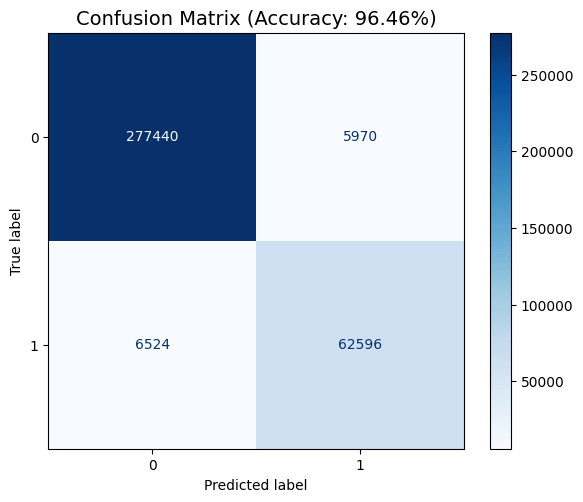


Confusion matrix saved as 'confusion_matrix.png'.


In [30]:
# ── 6. Confusion Matrix Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_model.classes_)
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title(f"Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)", fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("\nConfusion matrix saved as 'confusion_matrix.png'.")

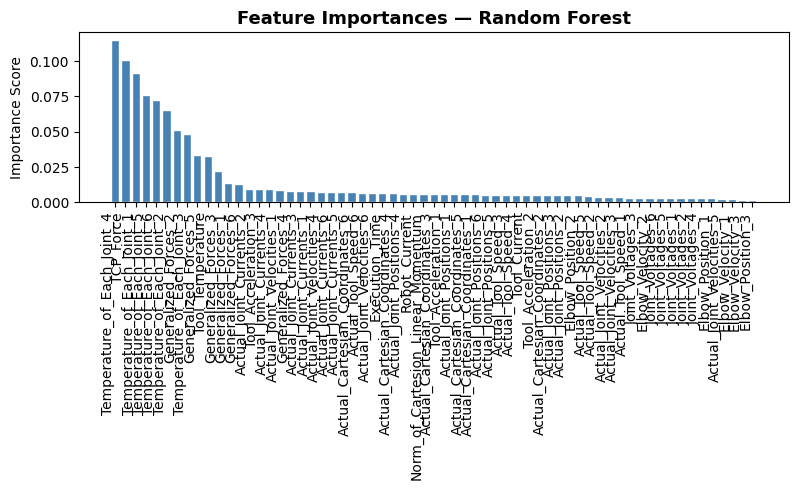

Feature importance plot saved as 'feature_importances.png'.


In [31]:
# ── 7. Feature Importance Plot ────────────────────────────────────────────────
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_
indices       = np.argsort(importances)[::-1]
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(feature_names)),
       importances[indices],
       color='steelblue', edgecolor='white')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=90, ha='right')
ax.set_ylabel('Importance Score')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=250)
plt.show()
print("Feature importance plot saved as 'feature_importances.png'.")

In [32]:
# ── 8. Per-feature importance table ──────────────────────────────────────────
importance_df = (
    pd.DataFrame({'Feature': feature_names,
                  'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
print("\nFeature Importance Ranking:")
print(importance_df.to_string(index=False))


Feature Importance Ranking:
                          Feature  Importance
      Temperature_of_Each_Joint_4    0.114699
                        TCP_Force    0.100517
      Temperature_of_Each_Joint_1    0.091565
      Temperature_of_Each_Joint_5    0.075818
      Temperature_of_Each_Joint_6    0.072247
      Temperature_of_Each_Joint_2    0.065326
             Generalized_Forces_2    0.051487
      Temperature_of_Each_Joint_3    0.048307
             Generalized_Forces_5    0.033210
                 Tool_Temperature    0.032957
             Generalized_Forces_3    0.022230
             Generalized_Forces_1    0.013425
             Generalized_Forces_6    0.013277
          Actual_Joint_Currents_2    0.009429
              Tool_Acceleration_3    0.009298
          Actual_Joint_Currents_4    0.009185
        Actual_Joint_Velocities_1    0.008656
             Generalized_Forces_4    0.008334
          Actual_Joint_Currents_3    0.008136
          Actual_Joint_Currents_1    0.007833
     

In [33]:
import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


In [34]:
# Retrain the model with fewer trees — 50 is usually enough for SHAP
rf_model = RandomForestClassifier(
    n_estimators=50,       # ← reduced from 100
    max_depth=10,          # ← limit tree depth (big speed improvement)
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_model)

In [42]:
# Compute SHAP values on the test set
# For large datasets, use a sample to keep it fast
sample_size = min(1000, len(X_test))   # use up to 1000 rows
X_sample = X_test.sample(n=sample_size, random_state=42)
 
print(f"Computing SHAP values on {sample_size} samples...")
shap_values = explainer.shap_values(X_sample)
 
# For binary classification, shap_values is a list [class_0, class_1]
# We take class_1 (anomaly = 1) for interpretation
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # class 1 = Anomaly
    expected_value = explainer.expected_value[1]
else:
    shap_vals = shap_values
    expected_value = explainer.expected_value
 
print(f"SHAP values shape: {shap_vals.shape}")
print("SHAP computation complete.")

Computing SHAP values on 1000 samples...
SHAP values shape: (1000, 63, 2)
SHAP computation complete.


Task was destroyed but it is pending!
task: <Task pending name='Task-229' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-230' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/transforms.py:109: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __init__(self, shorthand_name=None):
Task was destroyed but it is pending!
task: <Task pending name='Task-230' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/l

Raw SHAP type  : <class 'numpy.ndarray'>
Format: 3D array → sliced [:, :, 1]
Final SHAP shape : (1000, 63)
Base value       : 0.1961100473718549


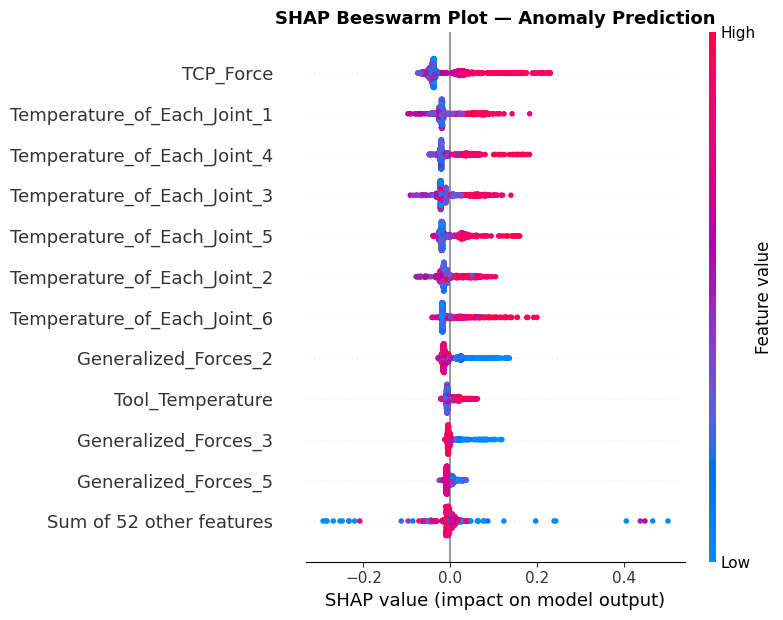

Saved: shap_beeswarm.png


In [43]:
# ── Step 1: Auto-handle all SHAP output formats ───────────────────────────────
print(f"Raw SHAP type  : {type(shap_values)}")

if isinstance(shap_values, list):
    # Format A: list of arrays → one per class [(n, f), (n, f)]
    shap_vals_plot = shap_values[1]
    base_val       = explainer.expected_value[1]
    print(f"Format: list → selected class 1")

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Format B: 3D array → (samples, features, classes)
    shap_vals_plot = shap_values[:, :, 1]
    base_val       = explainer.expected_value[1]
    print(f"Format: 3D array → sliced [:, :, 1]")

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    # Format C: already 2D (regression or single output)
    shap_vals_plot = shap_values
    base_val       = explainer.expected_value
    print(f"Format: 2D array → used directly")

else:
    raise ValueError(f"Unexpected SHAP values format: {type(shap_values)}, shape: {np.array(shap_values).shape}")

print(f"Final SHAP shape : {shap_vals_plot.shape}")   # must be (n_samples, n_features)
print(f"Base value       : {base_val}")

# ── Step 2: Build Explanation object ─────────────────────────────────────────
shap_explanation = shap.Explanation(
    values=shap_vals_plot,
    base_values=base_val,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

# ── Step 3: Beeswarm Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, max_display=12, show=False)
plt.title('SHAP Beeswarm Plot — Anomaly Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")


Generating SHAP Bar Plot...


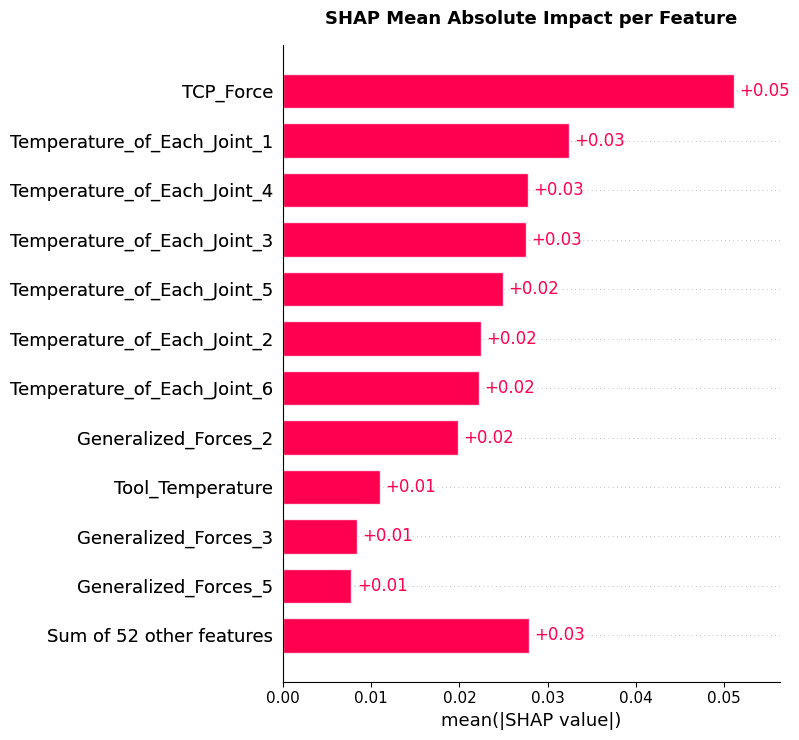

Saved: shap_bar.png


In [44]:
# Clean summary of which features matter most overall
print("\nGenerating SHAP Bar Plot...")
 
plt.figure(figsize=(9, 6))
shap.plots.bar(
    shap_explanation,
    max_display=12,
    show=False
)
plt.title('SHAP Mean Absolute Impact per Feature',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

Plotting PDPs for: ['TCP_Force', 'Temperature_of_Each_Joint_1', 'Temperature_of_Each_Joint_3', 'Temperature_of_Each_Joint_4', 'Temperature_of_Each_Joint_5', 'Temperature_of_Each_Joint_2', 'Temperature_of_Each_Joint_6', 'Generalized_Forces_2', 'Tool_Temperature', 'Generalized_Forces_3', 'Generalized_Forces_5', 'Generalized_Forces_1']


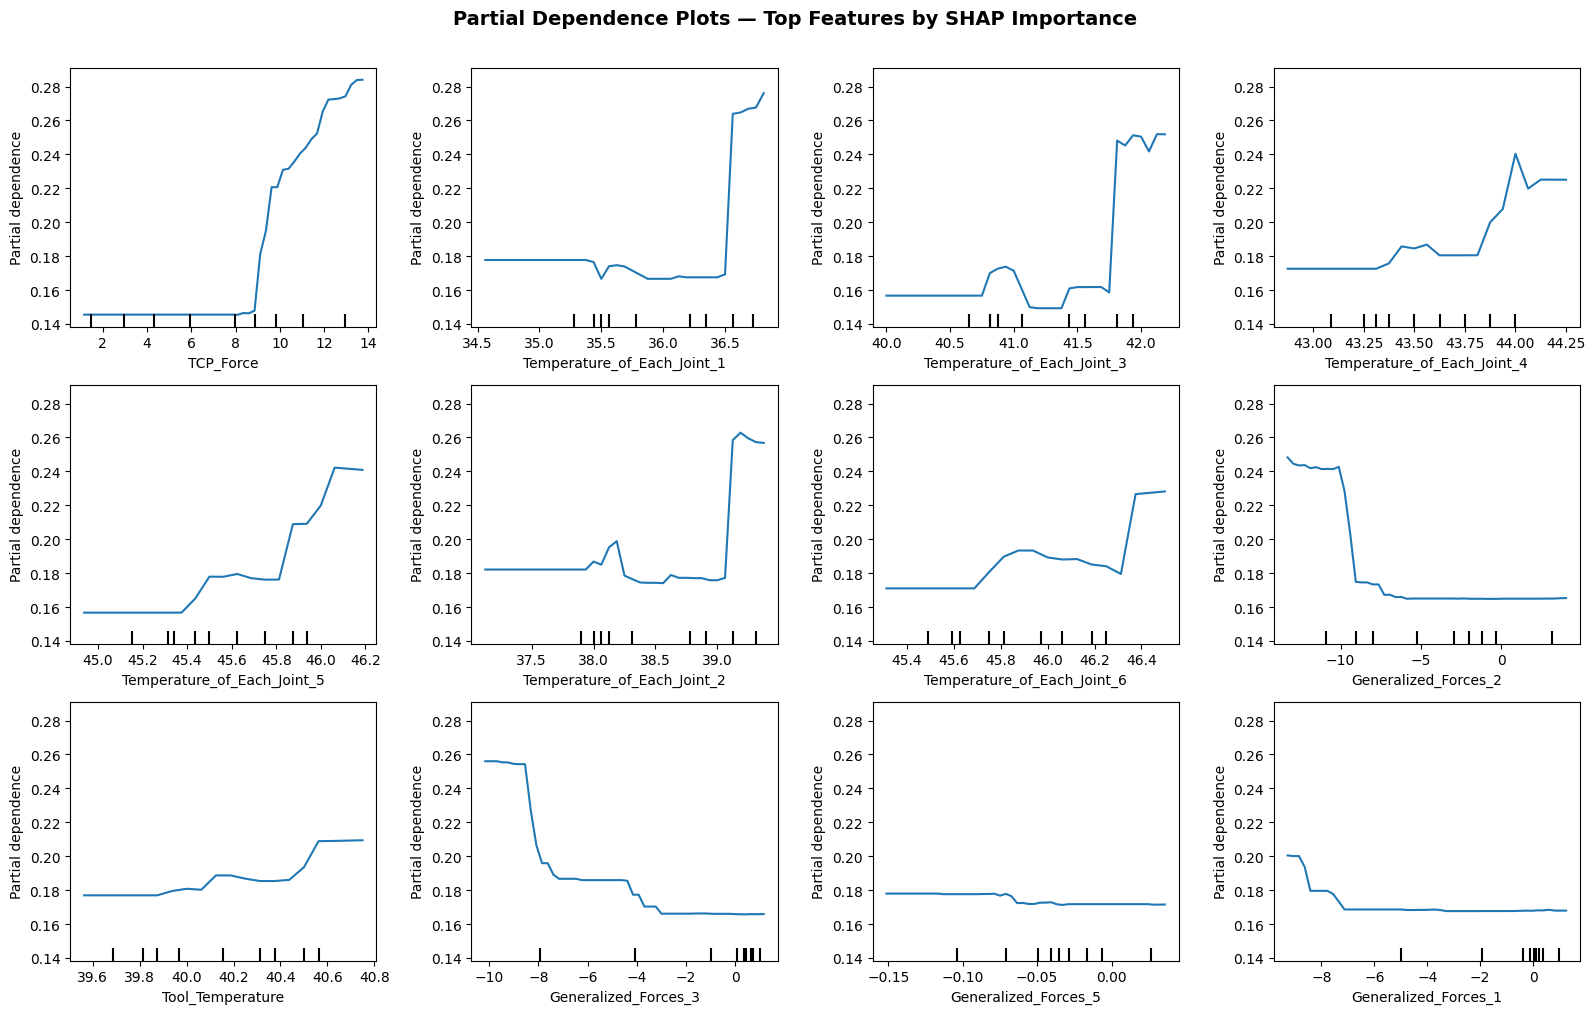

Saved: pdp_plots.png


In [38]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np

# ── Top features by SHAP importance ──────────────────────────────────────────
mean_shap     = np.abs(shap_vals_plot).mean(axis=0)
feature_names = X_sample.columns.tolist()
top_n         = min(12, len(feature_names))
top_indices   = np.argsort(mean_shap)[::-1][:top_n].tolist()   # .tolist() is critical
top_features  = [feature_names[i] for i in top_indices]

print(f"Plotting PDPs for: {top_features}")

# ── PDP Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_sample,
    features=top_indices,               # use integer indices
    feature_names=feature_names,
    kind='average',                     # 'average' = PDP only
    grid_resolution=50,
    ax=axes.flatten()[:top_n],
    random_state=42
)

# Hide unused subplots
for i in range(top_n, len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle('Partial Dependence Plots — Top Features by SHAP Importance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pdp_plots.png")

Plotting PDPs for: ['TCP_Force', 'Temperature_of_Each_Joint_1', 'Temperature_of_Each_Joint_3', 'Temperature_of_Each_Joint_4', 'Temperature_of_Each_Joint_5', 'Temperature_of_Each_Joint_2', 'Temperature_of_Each_Joint_6', 'Generalized_Forces_2', 'Tool_Temperature', 'Generalized_Forces_3', 'Generalized_Forces_5', 'Generalized_Forces_1']


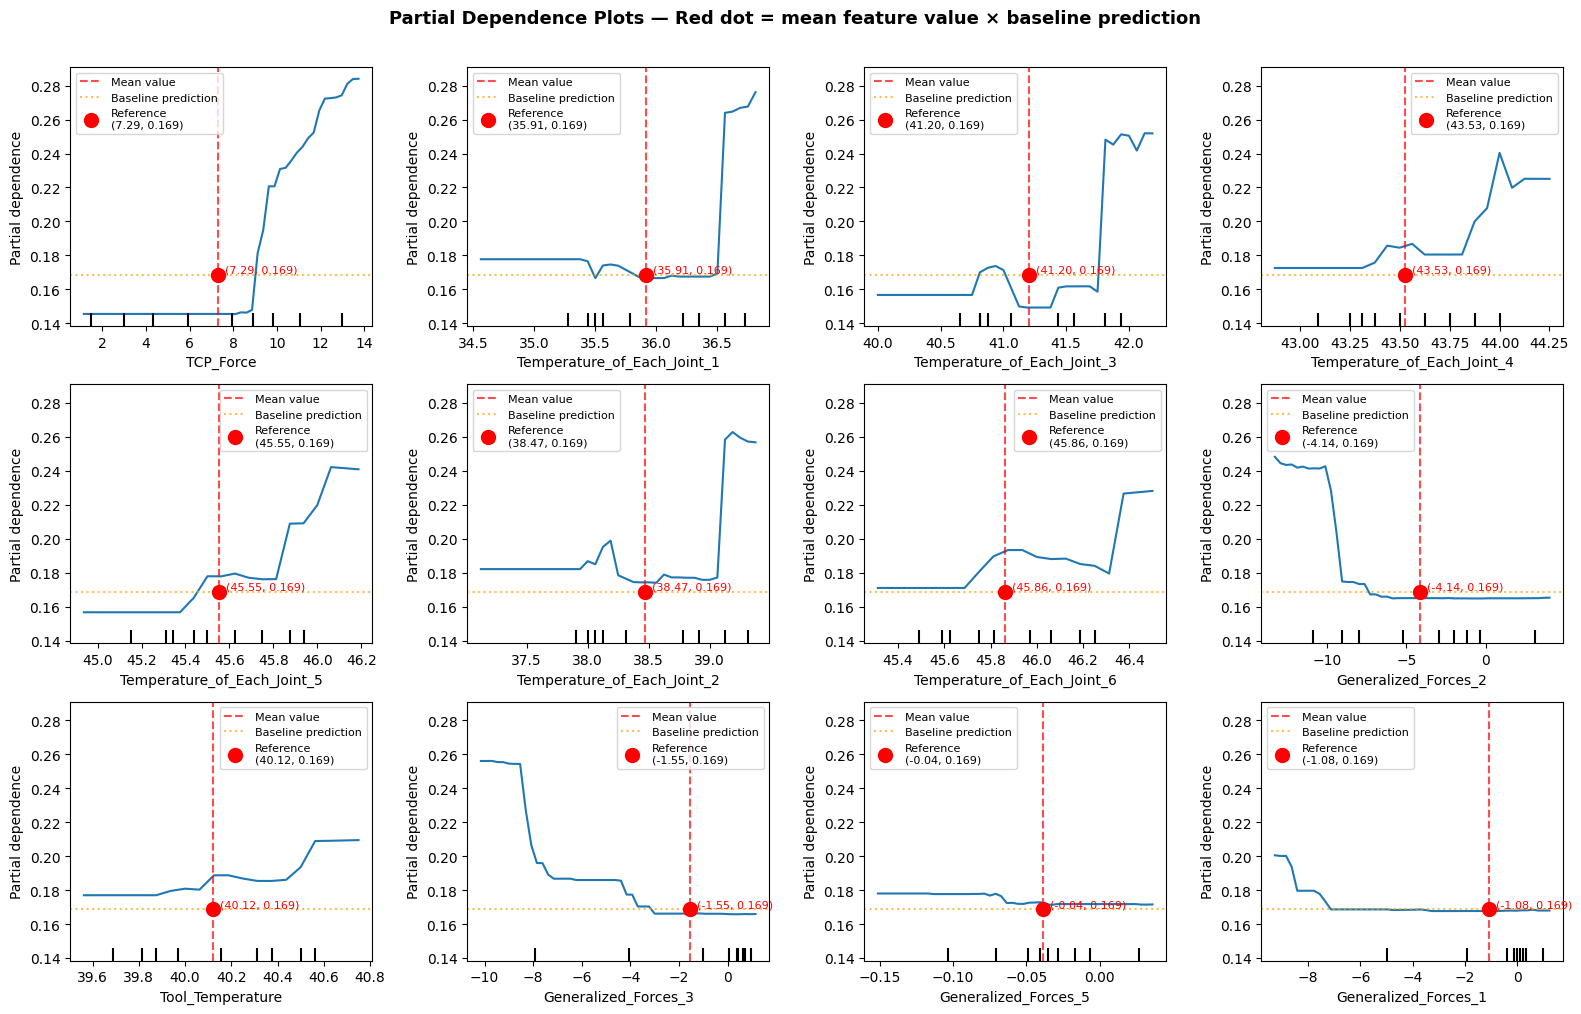

Saved: pdp_with_reference.png


In [39]:
from sklearn.inspection import PartialDependenceDisplay

# ── Top features by SHAP importance ──────────────────────────────────────────
mean_shap     = np.abs(shap_vals_plot).mean(axis=0)
feature_names = X_sample.columns.tolist()
top_n         = min(12, len(feature_names))
top_indices   = np.argsort(mean_shap)[::-1][:top_n].tolist()
top_features  = [feature_names[i] for i in top_indices]

print(f"Plotting PDPs for: {top_features}")

# ── PDP Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
flat_axes = axes.flatten()

disp = PartialDependenceDisplay.from_estimator(
    rf_model,
    X_sample,
    features=top_indices,
    feature_names=feature_names,
    kind='average',
    grid_resolution=50,
    ax=flat_axes[:top_n],
    random_state=42
)

# ── Add red reference point on each subplot ───────────────────────────────────
for i, (feat_idx, feat_name) in enumerate(zip(top_indices, top_features)):
    ax = flat_axes[i]

    # Reference x = mean of the feature
    ref_x = float(X_sample[feat_name].mean())

    # Reference y = model prediction at mean feature value (baseline probability)
    ref_y = rf_model.predict_proba(X_sample)[:, 1].mean()

    # Vertical dashed line at mean feature value
    ax.axvline(
        x=ref_x,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label='Mean value'
    )

    # Horizontal dashed line at baseline prediction
    ax.axhline(
        y=ref_y,
        color='orange',
        linestyle=':',
        linewidth=1.5,
        alpha=0.7,
        label='Baseline prediction'
    )

    # Red dot at the intersection of mean x and baseline y
    ax.scatter(
        ref_x, ref_y,
        color='red',
        s=100,                  # dot size
        zorder=5,               # draw on top of everything
        label=f'Reference\n({ref_x:.2f}, {ref_y:.3f})'
    )

    # Annotate the red dot with its coordinates
    ax.annotate(
        f'  ({ref_x:.2f}, {ref_y:.3f})',
        xy=(ref_x, ref_y),
        fontsize=8,
        color='red',
        va='bottom'
    )

    ax.legend(fontsize=8, loc='best')
    # ax.set_title(f'PDP — {feat_name}', fontsize=10, fontweight='bold')

# Hide unused subplots
for i in range(top_n, len(flat_axes)):
    flat_axes[i].set_visible(False)

fig.suptitle('Partial Dependence Plots — Red dot = mean feature value × baseline prediction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pdp_with_reference.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pdp_with_reference.png")

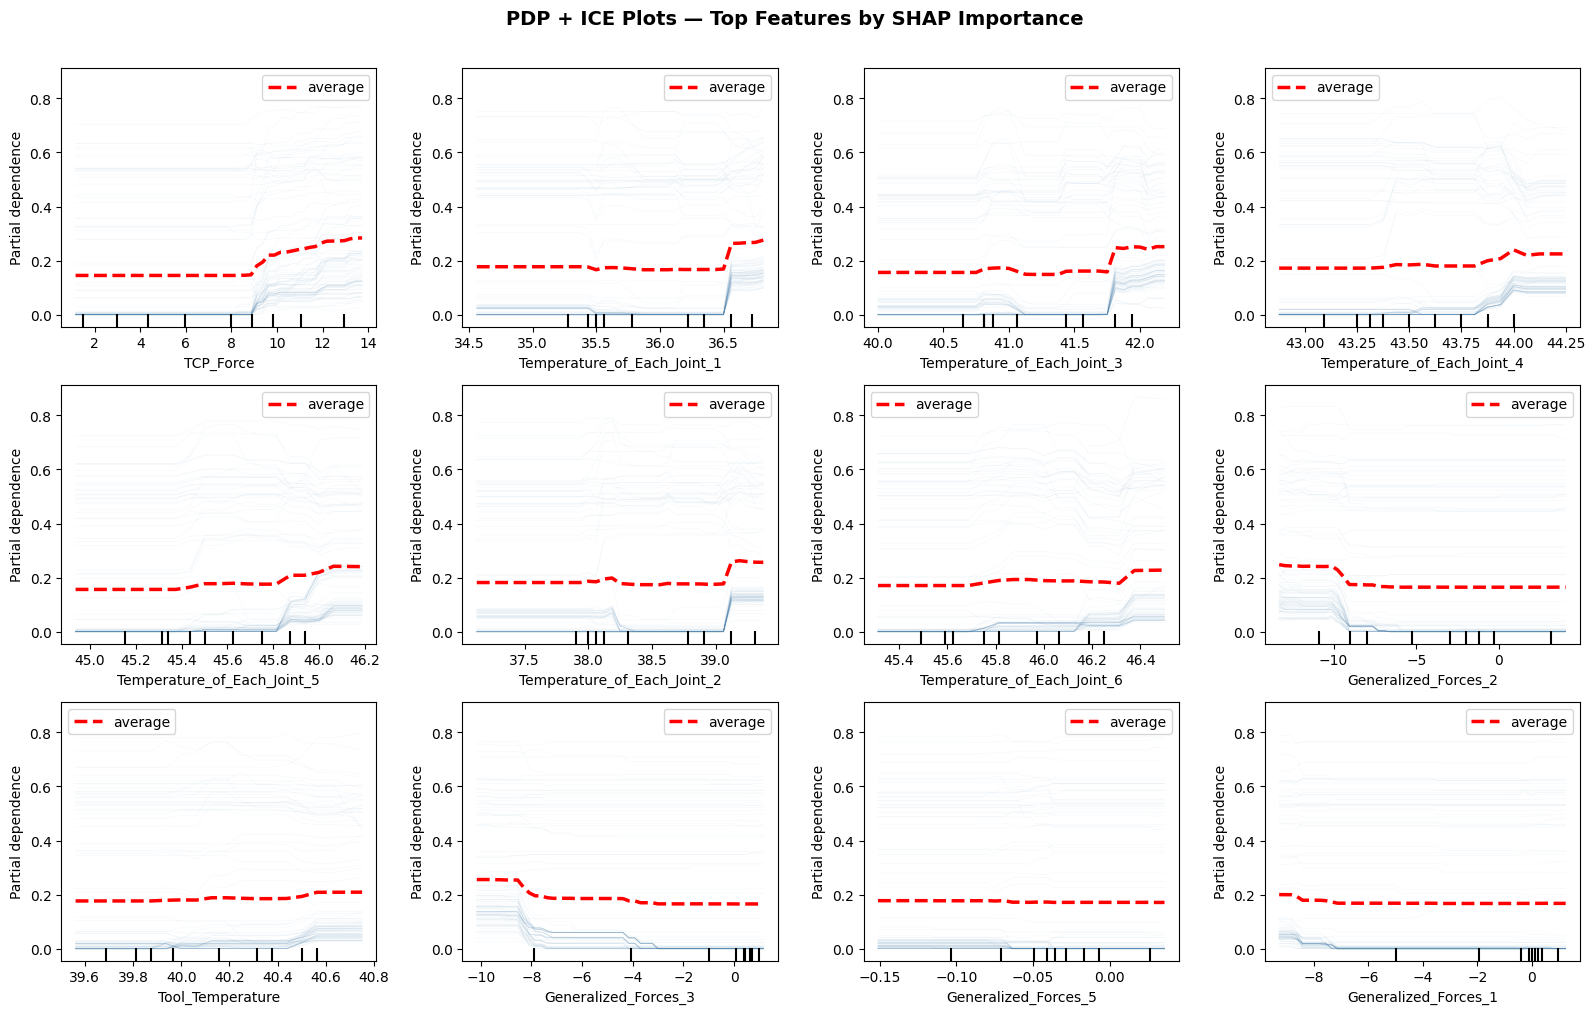

Saved: pdp_ice_plots.png


In [40]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_sample,
    features=top_indices,
    feature_names=feature_names,
    kind='both',                        # 'both' = PDP + ICE curves
    subsample=200,                      # limit ICE lines for speed
    grid_resolution=50,
    ax=axes.flatten()[:top_n],
    random_state=42,
    ice_lines_kw={'alpha': 0.05,        # ICE lines very transparent
                  'color': 'steelblue'},
    pd_line_kw={'color': 'red',         # mean PDP line in red
                'linewidth': 2.5}
)

for i in range(top_n, len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle('PDP + ICE Plots — Top Features by SHAP Importance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pdp_ice_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pdp_ice_plots.png")

In [41]:
shap_summary = (
    pd.DataFrame({
        'Feature':            feature_names,
        'Mean_Abs_SHAP':      mean_shap,
        'Mean_SHAP':          shap_vals.mean(axis=0),
    })
    .sort_values('Mean_Abs_SHAP', ascending=False)
    .reset_index(drop=True)
)
 
shap_summary.index += 1   # rank starts from 1
print("\nSHAP Feature Importance Ranking:")
print(shap_summary.to_string())
 

ValueError: Per-column arrays must each be 1-dimensional